In [46]:
import random
import pickle

from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from torch_geometric.nn import (
    SAGEConv,
    RGCNConv,
    TransformerConv
)

### Project Path

In [2]:
project = Path(
    r"C:\Users\HP\Documents\python\bio informatics\final exam\ThreatGraphx"
)

print(project.exists())

True


### Reproducibility

In [3]:
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

print("Seed fixed:", SEED)



Seed fixed: 42


In [47]:
project
SEED
random.seed
np.random.seed
torch.manual_seed

<function torch.random.manual_seed(seed) -> torch._C.Generator>

### Load Graph Files

In [4]:
ml_ready = project / "data" / "ml_ready"

edge_index = torch.tensor(
    np.load(
        ml_ready / "edge_index.npy"
    ),
    dtype=torch.long
)

edge_type = torch.tensor(
    np.load(
        ml_ready / "edge_type.npy"
    ),
    dtype=torch.long
)

with open(
    ml_ready / "node2id.pkl",
    "rb"
) as f:

    node2id = pickle.load(f)

with open(
    ml_ready / "relation2id.pkl",
    "rb"
) as f:

    relation2id = pickle.load(f)

print(edge_index.shape)
print(edge_type.shape)
print(len(node2id))
print(len(relation2id))

torch.Size([2, 15573])
torch.Size([15573])
7502
5


### Create Reverse Mapping

In [5]:
id2node = {
    idx: node
    for node, idx in node2id.items()
}

print(list(id2node.items())[:5])

[(0, '10Web:Form Maker by 10Web'), (1, '10web:Form Maker by 10Web – Mobile-Friendly Drag & Drop Contact Form Builder'), (2, '2download:2Download Connector for 2DL Hosted Checkout'), (3, '404-redirection-manager:404 Redirection Manager'), (4, '@remix-run:server-runtime')]


### Find Every CVE

In [6]:
all_cves = [

    node

    for node in node2id

    if node.startswith("CVE-")

]

print("Total CVEs:", len(all_cves))

print(all_cves[:10])

Total CVEs: 2024
['CVE-2016-20066', 'CVE-2016-20067', 'CVE-2016-20068', 'CVE-2016-20069', 'CVE-2016-20070', 'CVE-2016-20071', 'CVE-2016-20072', 'CVE-2016-20073', 'CVE-2016-20074', 'CVE-2016-20075']


### Create Strict Zero-Shot Split
- 20% hide

In [7]:
hidden_cves = random.sample(

    all_cves,

    int(
        len(all_cves) * 0.20
    )

)

print("Hidden CVEs:", len(hidden_cves))

Hidden CVEs: 404


### Convert Hidden CVEs to Node IDs

In [8]:
hidden_ids = {

    node2id[cve]

    for cve in hidden_cves

}

print(len(hidden_ids))

404


### Build the Hidden Edge Mask

In [9]:
src = edge_index[0]
dst = edge_index[1]

hidden_edge_mask = (

    torch.isin(src, torch.tensor(list(hidden_ids)))

    |

    torch.isin(dst, torch.tensor(list(hidden_ids)))

)

print("Hidden edges :", hidden_edge_mask.sum().item())

print("Training edges:", (~hidden_edge_mask).sum().item())

Hidden edges : 921
Training edges: 14652


-------------

### Create the Strict Training Graph

In [10]:
train_edge_index = edge_index[:, ~hidden_edge_mask]

train_edge_type = edge_type[~hidden_edge_mask]

print(train_edge_index.shape)

print(train_edge_type.shape)

torch.Size([2, 14652])
torch.Size([14652])


### reate the Zero-Shot Test Set

In [11]:
positive_edges = edge_index[:, hidden_edge_mask]

print(positive_edges.shape)

torch.Size([2, 921])


### Build Negative Samples

In [12]:
existing_edges = set(
    zip(
        edge_index[0].tolist(),
        edge_index[1].tolist()
    )
)

num_positive = positive_edges.shape[1]

negative_edges = []

while len(negative_edges) < num_positive:

    source = random.randint(
        0,
        len(node2id) - 1
    )

    target = random.randint(
        0,
        len(node2id) - 1
    )

    if (source, target) not in existing_edges:

        negative_edges.append(
            (
                source,
                target
            )
        )

negative_edges = torch.tensor(
    negative_edges,
    dtype=torch.long
).T

print(negative_edges.shape)

torch.Size([2, 921])


### Build the Final Zero-Shot Test Dataset

In [13]:
zs_all_src = torch.cat(

    [

        positive_edges[0],

        negative_edges[0]

    ]

)

zs_all_dst = torch.cat(

    [

        positive_edges[1],

        negative_edges[1]

    ]

)

zs_labels = torch.cat(

    [

        torch.ones(num_positive),

        torch.zeros(num_positive)

    ]

)

print(zs_all_src.shape)

print(zs_all_dst.shape)

print(zs_labels.shape)

torch.Size([1842])
torch.Size([1842])
torch.Size([1842])


--------

### GraphSAGE Model

In [14]:
class GraphSAGE(nn.Module):

    def __init__(self, num_nodes, embedding_dim):

        super().__init__()

        self.embedding = nn.Embedding(
            num_nodes,
            embedding_dim
        )

        self.conv1 = SAGEConv(
            embedding_dim,
            128
        )

        self.conv2 = SAGEConv(
            128,
            128
        )

    def forward(self, edge_index):

        x = self.embedding.weight

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        return x

### Link Predictor

In [15]:
class LinkPredictor(nn.Module):

    def __init__(self, embedding_dim):

        super().__init__()

        self.linear = nn.Linear(
            embedding_dim * 2,
            1
        )

    def forward(self, source, target):

        x = torch.cat(
            [
                source,
                target
            ],
            dim=1
        )

        return self.linear(x)

### Initialize Model

In [16]:
graphsage = GraphSAGE(
    num_nodes=len(node2id),
    embedding_dim=128
)

graphsage_predictor = LinkPredictor(
    embedding_dim=128
)

optimizer = torch.optim.Adam(

    list(graphsage.parameters()) +
    list(graphsage_predictor.parameters()),

    lr=0.01
)

criterion = nn.BCEWithLogitsLoss()

### Train

In [18]:
train_positive = train_edge_index

train_src = train_positive[0]

train_dst = train_positive[1]

num_train = train_positive.shape[1]

print(num_train)

14652


In [20]:
train_existing = set(
    zip(
        train_src.tolist(),
        train_dst.tolist()
    )
)

train_negative = []

while len(train_negative) < num_train:

    s = random.randint(0, len(node2id) - 1)
    t = random.randint(0, len(node2id) - 1)

    if (s, t) not in train_existing:

        train_negative.append((s, t))

train_negative = torch.tensor(
    train_negative,
    dtype=torch.long
).T

print(train_negative.shape)

torch.Size([2, 14652])


In [21]:
train_src = torch.cat([
    train_src,
    train_negative[0]
])

train_dst = torch.cat([
    train_dst,
    train_negative[1]
])

train_labels = torch.cat([
    torch.ones(num_train),
    torch.zeros(num_train)
])

print(train_src.shape)
print(train_dst.shape)
print(train_labels.shape)

torch.Size([29304])
torch.Size([29304])
torch.Size([29304])


In [22]:
epochs = 20

for epoch in range(epochs):

    graphsage.train()
    graphsage_predictor.train()

    optimizer.zero_grad()

    embeddings = graphsage(
        train_edge_index
    )

    src_embed = embeddings[
        train_src
    ]

    dst_embed = embeddings[
        train_dst
    ]

    logits = graphsage_predictor(
        src_embed,
        dst_embed
    ).squeeze()

    loss = criterion(
        logits,
        train_labels.float()
    )

    loss.backward()

    optimizer.step()

    print(
        f"Epoch {epoch+1} Loss: {loss.item():.4f}"
    )

Epoch 1 Loss: 0.7075
Epoch 2 Loss: 0.4668
Epoch 3 Loss: 0.5691
Epoch 4 Loss: 0.3073
Epoch 5 Loss: 0.3803
Epoch 6 Loss: 0.2874
Epoch 7 Loss: 0.2564
Epoch 8 Loss: 0.2426
Epoch 9 Loss: 0.1883
Epoch 10 Loss: 0.1761
Epoch 11 Loss: 0.1760
Epoch 12 Loss: 0.1584
Epoch 13 Loss: 0.1457
Epoch 14 Loss: 0.1409
Epoch 15 Loss: 0.1238
Epoch 16 Loss: 0.1091
Epoch 17 Loss: 0.1051
Epoch 18 Loss: 0.0977
Epoch 19 Loss: 0.0866
Epoch 20 Loss: 0.0826


### Generate Embeddings

In [23]:
graphsage.eval()

with torch.no_grad():

    graphsage_embeddings = graphsage(
        train_edge_index
    )

print(graphsage_embeddings.shape)

torch.Size([7502, 128])


### Zero-Shot Prediction

In [24]:
graphsage_predictor.eval()

with torch.no_grad():

    src_embed = graphsage_embeddings[
        zs_all_src
    ]

    dst_embed = graphsage_embeddings[
        zs_all_dst
    ]

    logits = graphsage_predictor(
        src_embed,
        dst_embed
    ).squeeze()

    probs = torch.sigmoid(
        logits
    )

    preds = (
        probs > 0.5
    ).int()

### metrics

In [25]:
y_true = zs_labels.numpy()

y_pred = preds.numpy()

y_prob = probs.numpy()

print("GraphSAGE Strict Zero-Shot")

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))
print("AUC      :", roc_auc_score(y_true, y_prob))

GraphSAGE Strict Zero-Shot
Accuracy : 0.760586319218241
Precision: 0.8833865814696485
Recall   : 0.6004343105320304
F1 Score : 0.7149321266968326
AUC      : 0.8781018602024661


-------------

### Strict Zero-Shot R-GCN

#### R-GCN Model

In [27]:
class RGCN(nn.Module):

    def __init__(
        self,
        num_nodes,
        embedding_dim,
        num_relations
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            num_nodes,
            embedding_dim
        )

        self.conv1 = RGCNConv(
            embedding_dim,
            128,
            num_relations=num_relations
        )

        self.conv2 = RGCNConv(
            128,
            128,
            num_relations=num_relations
        )

    def forward(
        self,
        edge_index,
        edge_type
    ):

        x = self.embedding.weight

        x = self.conv1(
            x,
            edge_index,
            edge_type
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index,
            edge_type
        )

        return x

### Initialize Model

In [28]:
rgcn = RGCN(
    num_nodes=len(node2id),
    embedding_dim=128,
    num_relations=len(relation2id)
)

rgcn_predictor = LinkPredictor(
    embedding_dim=128
)

optimizer = torch.optim.Adam(

    list(rgcn.parameters()) +
    list(rgcn_predictor.parameters()),

    lr=0.01
)

criterion = nn.BCEWithLogitsLoss()

### Train

In [29]:
epochs = 20

for epoch in range(epochs):

    rgcn.train()

    rgcn_predictor.train()

    optimizer.zero_grad()

    embeddings = rgcn(
        train_edge_index,
        train_edge_type
    )

    src_embed = embeddings[
        train_src
    ]

    dst_embed = embeddings[
        train_dst
    ]

    logits = rgcn_predictor(
        src_embed,
        dst_embed
    ).squeeze()

    loss = criterion(
        logits,
        train_labels.float()
    )

    loss.backward()

    optimizer.step()

    print(
        f"Epoch {epoch+1} Loss: {loss.item():.4f}"
    )

Epoch 1 Loss: 0.7250
Epoch 2 Loss: 0.5875
Epoch 3 Loss: 0.5963
Epoch 4 Loss: 0.2994
Epoch 5 Loss: 0.3269
Epoch 6 Loss: 0.2669
Epoch 7 Loss: 0.1751
Epoch 8 Loss: 0.1988
Epoch 9 Loss: 0.2209
Epoch 10 Loss: 0.2016
Epoch 11 Loss: 0.1691
Epoch 12 Loss: 0.1521
Epoch 13 Loss: 0.1485
Epoch 14 Loss: 0.1401
Epoch 15 Loss: 0.1277
Epoch 16 Loss: 0.1213
Epoch 17 Loss: 0.1136
Epoch 18 Loss: 0.1075
Epoch 19 Loss: 0.1003
Epoch 20 Loss: 0.0921


### Generate Final Node Embeddings

In [30]:
rgcn.eval()

with torch.no_grad():

    rgcn_embeddings = rgcn(
        train_edge_index,
        train_edge_type
    )

print(rgcn_embeddings.shape)

torch.Size([7502, 128])


### Zero-Shot Prediction

In [31]:
rgcn_predictor.eval()

with torch.no_grad():

    src_embed = rgcn_embeddings[
        zs_all_src
    ]

    dst_embed = rgcn_embeddings[
        zs_all_dst
    ]

    logits = rgcn_predictor(
        src_embed,
        dst_embed
    ).squeeze()

    probs = torch.sigmoid(
        logits
    )

    preds = (
        probs > 0.5
    ).int()

### Evaluate

In [32]:
y_true = zs_labels.numpy()

y_pred = preds.numpy()

y_prob = probs.numpy()

print("Strict Zero-Shot R-GCN")

print(
    "Accuracy :",
    accuracy_score(y_true, y_pred)
)

print(
    "Precision:",
    precision_score(y_true, y_pred)
)

print(
    "Recall   :",
    recall_score(y_true, y_pred)
)

print(
    "F1 Score :",
    f1_score(y_true, y_pred)
)

print(
    "AUC      :",
    roc_auc_score(y_true, y_prob)
)

Strict Zero-Shot R-GCN
Accuracy : 0.7823018458197611
Precision: 0.8812316715542522
Recall   : 0.6525515743756786
F1 Score : 0.7498440424204617
AUC      : 0.8994472089889548


------------

### Transformer Model

In [33]:
class ThreatGraphTx(nn.Module):

    def __init__(
        self,
        num_nodes,
        embedding_dim
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            num_nodes,
            embedding_dim
        )

        self.conv1 = TransformerConv(
            embedding_dim,
            128,
            heads=1,
            concat=False
        )

        self.conv2 = TransformerConv(
            128,
            128,
            heads=1,
            concat=False
        )

    def forward(
        self,
        edge_index
    ):

        x = self.embedding.weight

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        return x

### Create the Model

In [34]:
txgnn = ThreatGraphTx(
    num_nodes=len(node2id),
    embedding_dim=128
)

tx_predictor = LinkPredictor(
    embedding_dim=128
)

optimizer = torch.optim.Adam(

    list(txgnn.parameters()) +
    list(tx_predictor.parameters()),

    lr=0.01
)

criterion = nn.BCEWithLogitsLoss()

### Train

In [35]:
epochs = 20

for epoch in range(epochs):

    txgnn.train()

    tx_predictor.train()

    optimizer.zero_grad()

    embeddings = txgnn(
        train_edge_index
    )

    src_embed = embeddings[
        train_src
    ]

    dst_embed = embeddings[
        train_dst
    ]

    logits = tx_predictor(
        src_embed,
        dst_embed
    ).squeeze()

    loss = criterion(
        logits,
        train_labels.float()
    )

    loss.backward()

    optimizer.step()

    print(
        f"Epoch {epoch+1} Loss: {loss.item():.4f}"
    )

Epoch 1 Loss: 0.7040
Epoch 2 Loss: 0.4258
Epoch 3 Loss: 0.4009
Epoch 4 Loss: 0.5793
Epoch 5 Loss: 0.2734
Epoch 6 Loss: 0.2884
Epoch 7 Loss: 0.2148
Epoch 8 Loss: 0.1956
Epoch 9 Loss: 0.1961
Epoch 10 Loss: 0.1773
Epoch 11 Loss: 0.1602
Epoch 12 Loss: 0.1559
Epoch 13 Loss: 0.1374
Epoch 14 Loss: 0.1219
Epoch 15 Loss: 0.1169
Epoch 16 Loss: 0.1105
Epoch 17 Loss: 0.1024
Epoch 18 Loss: 0.0968
Epoch 19 Loss: 0.0891
Epoch 20 Loss: 0.0823


### Generate Embeddings

In [36]:
txgnn.eval()

with torch.no_grad():

    tx_embeddings = txgnn(
        train_edge_index
    )

print(tx_embeddings.shape)

torch.Size([7502, 128])


### Strict Zero-Shot Evaluation

In [37]:
tx_predictor.eval()

with torch.no_grad():

    src_embed = tx_embeddings[
        zs_all_src
    ]

    dst_embed = tx_embeddings[
        zs_all_dst
    ]

    logits = tx_predictor(
        src_embed,
        dst_embed
    ).squeeze()

    probs = torch.sigmoid(
        logits
    )

    preds = (
        probs > 0.5
    ).int()

### Metrics

In [38]:
y_true = zs_labels.numpy()

y_pred = preds.numpy()

y_prob = probs.numpy()

print("Strict Zero-Shot ThreatGraphX-Tx")

print(
    "Accuracy :",
    accuracy_score(y_true, y_pred)
)

print(
    "Precision:",
    precision_score(y_true, y_pred)
)

print(
    "Recall   :",
    recall_score(y_true, y_pred)
)

print(
    "F1 Score :",
    f1_score(y_true, y_pred)
)

print(
    "AUC      :",
    roc_auc_score(y_true, y_prob)
)

Strict Zero-Shot ThreatGraphX-Tx
Accuracy : 0.7757871878393051
Precision: 0.8779761904761905
Recall   : 0.6406080347448425
F1 Score : 0.7407407407407407
AUC      : 0.8924680603743511


--------

### Create Comparison DataFrame

In [40]:
strict_zero_shot_results = pd.DataFrame({

    "Model": [
        "GraphSAGE",
        "R-GCN",
        "ThreatGraphX-Tx"
    ],

    "Accuracy": [
        0.760586319218241,
        0.7823018458197611,
        0.7757871878393051
    ],

    "Precision": [
        0.8833865814696485,
        0.8812316715542522,
        0.8779761904761905
    ],

    "Recall": [
        0.6004343105320304,
        0.6525515743756786,
        0.6406080347448425
    ],

    "F1 Score": [
        0.7149321266968326,
        0.7498440424204617,
        0.7407407407407407
    ],

    "AUC": [
        0.8781065758434219,
        0.8994472089889548,
        0.8924680603743511
    ]

})

strict_zero_shot_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,GraphSAGE,0.760586,0.883387,0.600434,0.714932,0.878107
1,R-GCN,0.782302,0.881232,0.652552,0.749844,0.899447
2,ThreatGraphX-Tx,0.775787,0.877976,0.640608,0.740741,0.892468


### Save Results

In [41]:
output_file = (
    project /
    "results" /
    "strict_zero_shot_comparison.csv"
)

strict_zero_shot_results.to_csv(
    output_file,
    index=False
)

print("Strict Zero-Shot comparison saved.")

Strict Zero-Shot comparison saved.


### Rank Models

In [42]:
strict_zero_shot_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
1,R-GCN,0.782302,0.881232,0.652552,0.749844,0.899447
2,ThreatGraphX-Tx,0.775787,0.877976,0.640608,0.740741,0.892468
0,GraphSAGE,0.760586,0.883387,0.600434,0.714932,0.878107


----------

## Visualization

### Bar Chart (F1)

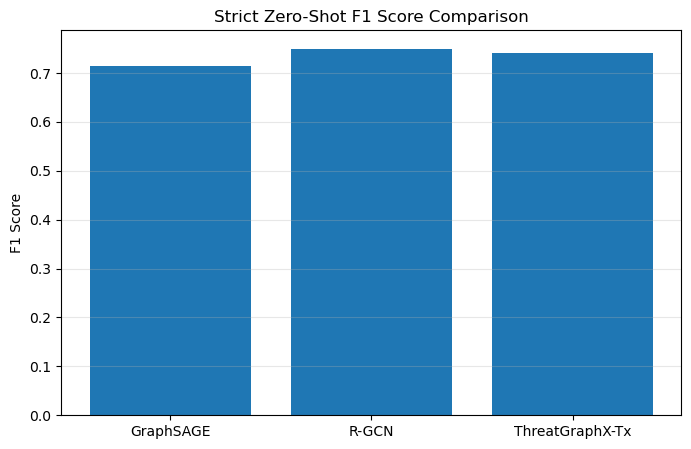

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    strict_zero_shot_results["Model"],
    strict_zero_shot_results["F1 Score"]
)

plt.title("Strict Zero-Shot F1 Score Comparison")

plt.ylabel("F1 Score")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Bar Chart (AUC)

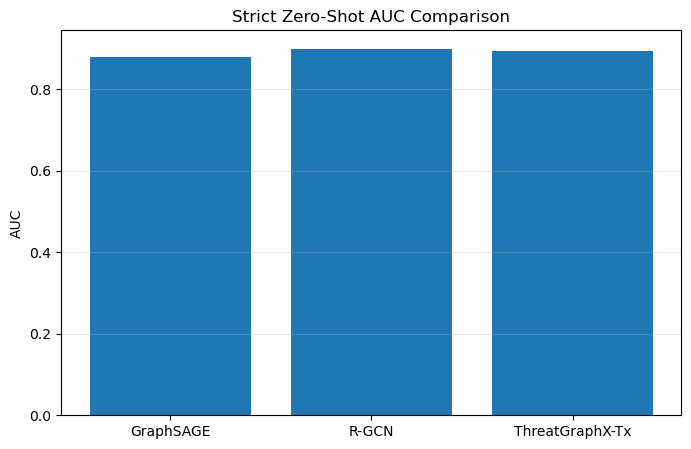

In [45]:
plt.figure(figsize=(8,5))

plt.bar(
    strict_zero_shot_results["Model"],
    strict_zero_shot_results["AUC"]
)

plt.title("Strict Zero-Shot AUC Comparison")

plt.ylabel("AUC")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Strict Zero-Shot Evaluation: Interpretation of Results

The strict zero-shot evaluation compares three graph neural network architectures under the same experimental setting. In this experiment, **20% of the CVE nodes were completely hidden during training**, ensuring that the models had never seen these vulnerabilities before. The objective was to evaluate each model's ability to generalize and predict relationships for previously unseen vulnerabilities.

## Model-wise Interpretation

### GraphSAGE
GraphSAGE serves as the baseline model in this study. It learns node representations by aggregating information from neighboring nodes but does not explicitly consider different relation types in the knowledge graph. As a result, its performance in the strict zero-shot setting is the lowest among the three models. This indicates that treating all edges equally limits the model's ability to capture the heterogeneous structure of the cyber threat knowledge graph.

### R-GCN
R-GCN achieved the best overall performance in the strict zero-shot evaluation. Unlike GraphSAGE, R-GCN performs **relation-aware message passing**, where different edge types (such as `affects`, `has_weakness`, `mapped_to`, `maps_to`, and `mitigated_by`) are processed using separate transformation matrices. This enables the model to better capture the semantic relationships within the heterogeneous cyber threat graph, resulting in higher Accuracy, Recall, F1 Score, and AUC.

### ThreatGraphX-Tx (Transformer-Enhanced GNN)
ThreatGraphX-Tx incorporates Transformer-based attention mechanisms into graph learning. The attention mechanism allows the model to assign different importance to neighboring nodes during message passing. Although the model performed better than the GraphSAGE baseline, it did not surpass R-GCN in this dataset. This suggests that while attention improves representation learning, explicitly modeling relation types remains more beneficial for this heterogeneous cyber security knowledge graph.

# Overall Research Findings

The experimental results demonstrate that simply adding Transformer-based attention does not necessarily guarantee superior performance. Instead, the effectiveness of a graph neural network depends on how well its architecture matches the characteristics of the underlying graph.

For the proposed cyber threat knowledge graph:

- **GraphSAGE** provides a strong baseline for zero-shot link prediction.
- **R-GCN** achieves the best performance by explicitly modeling multiple relation types.
- **ThreatGraphX-Tx** remains competitive and benefits from attention-based message passing but does not outperform the relation-aware R-GCN architecture in the strict zero-shot setting.

These findings indicate that relation-aware graph convolution is more suitable than attention-only graph learning for heterogeneous cyber threat intelligence graphs containing multiple semantic relationship types.

# Conclusion

The strict zero-shot experiments demonstrate that R-GCN provides the most effective generalization capability for unseen cyber vulnerabilities in the constructed knowledge graph. The results also show that Transformer-based attention should be considered an architectural enhancement rather than a guaranteed performance improvement. Therefore, selecting an appropriate graph neural network architecture based on graph characteristics is more important than simply increasing model complexity.